#  Energy Consumption Modeling for UAVs Based on Flight Data and Mission Parameters :
## 1. Data analysis and feature extraction

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from scipy.ndimage import gaussian_filter1d

In [2]:
from utils import clean_flight_df

### M100 Data

In [3]:
df = pd.read_csv(r".\12683453\flights.csv", delimiter=",", encoding="utf-8", header=0)
print(df.columns)


Index(['flight', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'speed', 'payload', 'altitude', 'date',
       'time_day', 'route'],
      dtype='object')


C:\Users\raman\AppData\Local\Temp\ipykernel_15228\2867343098.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r".\12683453\flights.csv", delimiter=",", encoding="utf-8", header=0)


### Data Cleaning

Sanity check

In [4]:
clean_df = clean_flight_df(df)

c:\Users\raman\Desktop\Kanchan_Material\01_AirTransportAndLogistics\Course_Material\Semester_03\Research Task\utils.py:250: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_day'] = pd.to_datetime(df['time_day'], errors='coerce').dt.time


### Find different phase of flight using  altitude, horizontal and vertical speed. 

In [5]:
# --- your preprocessing as before ---
df = df.sort_values(["flight", "time"]).reset_index(drop=True)
df["altitude_measured"] = df["position_z"] - df.groupby("flight")["position_z"].transform("first")
df["horizontal_speed"] = np.sqrt(df["velocity_x"]**2 + df["velocity_y"]**2)
df['alt_diff'] = df.groupby('flight')['altitude_measured'].diff()
df['max_altitude_flight'] = df.groupby('flight')['altitude_measured'].transform('max')
df['min_altitude_flight'] = df.groupby('flight')['altitude_measured'].transform('min')
df["dt"] = df.groupby("flight")["time"].diff()
df["vz_from_alt_raw"] = df["alt_diff"] / df["dt"]

df["vz_from_alt"] = (
    df.groupby("flight")["vz_from_alt_raw"]
      .transform(lambda x: gaussian_filter1d(x, sigma=5, mode="nearest"))
)

df["power_w"] = df["battery_voltage"] * df["battery_current"]

# --- classify phases from vertical speed ---
def classify_phase(vz):
    if vz < -0.6:
        return "Descent"
    elif vz > 0.6:
        return "Climb"
    else:
        return "Other"

df["phase_vz"] = df["vz_from_alt"].apply(classify_phase)


In [6]:
text_width = 9 #inch

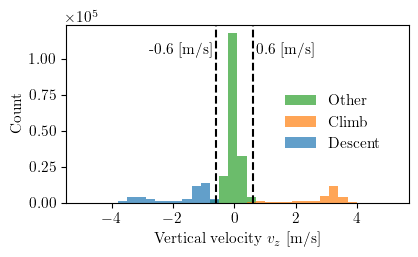

In [8]:
import matplotlib.pyplot as plt

# Set global font settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    'font.size':       11,
    'axes.titlesize':  11,
    'axes.labelsize':  11,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

# Create figure and axis
fig, ax = plt.subplots(figsize=(text_width*0.48, text_width*0.3))  # 10x8 inches (equivalent to 800x600 pixels)

# Define color mapping
colors = {
    "Descent": "C0",
    "Climb": "C1",
    "Other": "C2"
}

# Get unique phases
phases = df["phase_vz"].unique()

vz_data = df["vz_from_alt"]
bin_size = 0.3
nbins = np.arange(np.floor(vz_data.min()), np.ceil(vz_data.max()) + bin_size, bin_size)

# Create histogram for each phase
for phase in phases:
    # Filter data for this phase
    phase_data = df[df["phase_vz"] == phase]["vz_from_alt"]

    # Plot histogram with appropriate color
    ax.hist(phase_data,
            bins=nbins,
            alpha=0.7,
            label=phase,
            color=colors[phase],
            density=False)  # Use density=False for counts like plotly

# Add vertical lines at -0.6 and +0.6
ax.axvline(x=-0.6, linestyle='--', color='black')
ax.axvline(x=0.6, linestyle='--', color='black')

# Add annotations with LaTeX formatting
ax.annotate(r'-0.6 [m/s]', xy=(-0.6, 0), xytext=(-0.7, max(ax.get_ylim())*0.9),
            ha='right', va='top')
ax.annotate(r'0.6 [m/s]', xy=(0.6, 0), xytext=(0.7, max(ax.get_ylim())*0.9),
            ha='left', va='top')

# Set labels and title with LaTeX formatting
ax.set_xlabel(r"Vertical velocity $v_z$ [m/s]")
ax.set_ylabel("Count")
# ax.set_title("Vertical Speed Histogram by Phase")

# Add legend
ax.legend(bbox_to_anchor=(0.6, 0.45), frameon=False )

plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
# Adjust layout to prevent clipping
plt.tight_layout()

# Save figure
plt.savefig("vertical_speed_histogram_by_phase.pdf", dpi=300, bbox_inches='tight')
plt.show()

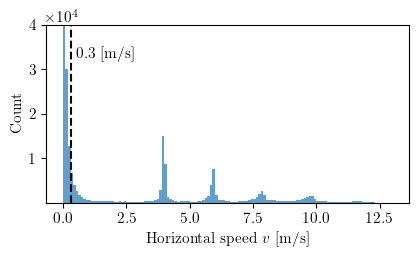

In [9]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(text_width*0.48, text_width*0.3))  # 10x8 inches (equivalent to 800x600 pixels)

vx = df["horizontal_speed"]
bin_size = 0.1
nbins = np.arange(np.floor(vx.min()), np.ceil(vx.max()) + bin_size, bin_size)

ax.hist(vx,
        bins=nbins,
        alpha=0.7,
        density=False)  # Use density=False for counts like plotly

ax.axvline(x=0.3, linestyle='--', color='black')

# Add annotations with LaTeX formatting
ax.annotate(r'0.3 [m/s]', xy=(0.3, 0), xytext=(0.5,35000),
            ha='left', va='top')

# Set labels and title with LaTeX formatting
ax.set_xlabel(r"Horizontal speed $v$ [m/s]")
ax.set_ylabel("Count")
ax.set_ylim(5,40000)


plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()

# Save figure
plt.savefig("horizontal_speed_hist.pdf", dpi=300, bbox_inches='tight')
plt.show()

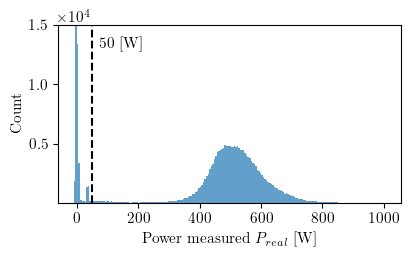

In [10]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(text_width*0.48, text_width*0.3))  # 10x8 inches (equivalent to 800x600 pixels)

power = df["power_w"]
bin_size = 5
nbins = np.arange(np.floor(power.min()), np.ceil(power.max()) + bin_size, bin_size)

ax.hist(power,
        bins=nbins,
        alpha=0.7,
        density=False)  # Use density=False for counts like plotly

ax.axvline(x=50, linestyle='--', color='black')

# Add annotations with LaTeX formatting
ax.annotate(r'50 [W]', xy=(50, 0), xytext=(74,14000),
            ha='left', va='top')

# Set labels and title with LaTeX formatting
ax.set_xlabel(r"Power measured $P_{real}$ [W]")
ax.set_ylabel("Count")
ax.set_ylim(5,15000)

plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()

# Save figure
plt.savefig("power_his.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Velocity from altitude diff and velocity_z are not same e.g. in 120
So lets do a sanity check.

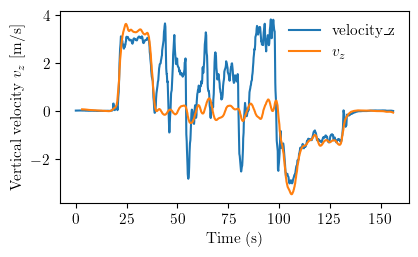

In [11]:
flights_to_plot = [79]                     # <-- list of flights you want to visualise

sub = df[df["flight"].isin(flights_to_plot)].copy()

n_flights = len(flights_to_plot)

fig, axes = plt.subplots(
    nrows=n_flights,
    ncols=1,
    sharex=True,               # same time axis for all panels
    figsize=(text_width*0.48, text_width*0.3),
)

# If only one flight, `axes` is not a list – make it iterable
if n_flights == 1:
    axes = [axes]

for ax, flight_id in zip(axes, flights_to_plot):
    # slice the data for the current flight
    df_f = sub[sub["flight"] == flight_id]

    # Plot the two signals
    ax.plot(
        df_f["time"],
        df_f["velocity_z"],
        label="velocity_z",
    )
    ax.plot(
        df_f["time"],
        df_f["vz_from_alt"],
        label=r"$v_z$",
    )

    # ---- axis titles -------------------------------------------------
    ax.set_ylabel(r"Vertical velocity $v_z$ [m/s]")

    # ---- grid / spines ------------------------------------------------
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")

    # ---- legend (only once, on the top panel) ------------------------
    if ax is axes[0]:
        ax.legend(loc="upper right", frameon=False)

axes[-1].set_xlabel(r"Time (s)")

plt.tight_layout()
plt.savefig(
    "vz_different_ways.pdf",
    bbox_inches="tight",
)
plt.show()

#### Definitions of various phases

In [12]:

# Thresholds
NEARLY_ZERO_HORIZONTAL_VEL   = 0.3   # m/s
NEARLY_ZERO_VERTICAL_VEL     = 0.2   # m/s

CRUISE_MAX_VERTICAL_VEL    = 0.6   # m/s
CRUISE_MIN_VERTICAL_VEL    = -0.6  # m/s

NEARLY_ZERO_POWER_W        = 50.0  # W   # max power to be considered taxiing

# Start with a default phase
df['phase'] = 'other'

# --- Taxi: low altitude, nearly no motion ---
taxi_mask = (
    (df['horizontal_speed'].abs() < NEARLY_ZERO_HORIZONTAL_VEL) &
    (df['vz_from_alt'].abs()      < NEARLY_ZERO_VERTICAL_VEL) &
    (df['power_w']      < NEARLY_ZERO_POWER_W)
)
df.loc[(df['phase'] == 'other') & taxi_mask, 'phase'] = 'taxi'


# --- Hover: nearly no motion ---
# 1. horizontal speed below hover max
# 2. vertical speed below hover max
hover_mask = (
    (df['horizontal_speed'].abs() < NEARLY_ZERO_HORIZONTAL_VEL) &
    (df['vz_from_alt'].abs()      < NEARLY_ZERO_VERTICAL_VEL)
)
df.loc[(df['phase'] == 'other') & hover_mask, 'phase'] = 'hover'

# --- Cruise: nearly no vertical motion, high altitude ---
# 1. vertical speed below cruise max
# 2. altitude above 80% of max altitude in flight
cruise_mask = (
    (df['vz_from_alt'] < CRUISE_MAX_VERTICAL_VEL) &
    (df['vz_from_alt'] > CRUISE_MIN_VERTICAL_VEL) &
    (df['altitude_measured'] > 0.8 * df['max_altitude_flight'])
)
df.loc[(df['phase'] == 'other') & cruise_mask, 'phase'] = 'cruise'

# ---- CLIMB ----
# 1. vertical speed is greater than climb vertical speed minimum
climb_mask = (df['vz_from_alt'] > CRUISE_MAX_VERTICAL_VEL)
df.loc[(df['phase'] == 'other') & climb_mask, 'phase'] = 'climb'

# ---- DESCENT ----
# 1. vertical speed is less than negative of climb vertical speed minimum
descent_mask = (df['vz_from_alt'] < CRUISE_MIN_VERTICAL_VEL)
df.loc[(df['phase'] == 'other') & descent_mask, 'phase'] = 'descent'




### Find percentage of other phase in data

In [13]:
other_count = (df['phase'] == 'other').sum()
total_count = len(df)

percentage_other = (other_count / total_count) * 100
print(f"Other data percentage: {percentage_other:.2f}%")



Other data percentage: 3.97%


### Visualize different phase of flight with Line graph

In [ ]:
from matplotlib.collections import PolyCollection
def plot_flight_altitude_speed_matplotlib(
    d,
    phase_colors,
    show=True,
):
    """
    Plot altitude, vertical speed, horizontal speed and phase bands using matplotlib.
    """
    # Prepare data
    y_min = d["altitude_measured"].min() - 1
    y_max = d["altitude_measured"].max() + 1

    # Create figure with twin axes
    fig, ax1 = plt.subplots(figsize=(text_width, text_width*0.48))
    ax2 = ax1.twinx()

    # ------------------ 1) Add Altitude (left axis) ------------------
    ax1.plot(d["time"], d["altitude_measured"], color="blue", label="Height (m)")

    # ------------------ 2) Add Vertical Speed (right axis) ------------------
    ax2.plot(d["time"], d["vz_from_alt"], color="red", label="Vertical speed (m/s)")

    # ------------------ 2b) Add Horizontal Speed (right axis) ------------------
    ax2.plot(d["time"], d["horizontal_speed"], color="green", label="Speed (m/s)")

    # ------------------ 3) Add Phase Bands as Filled Traces ------------------
    df = d.sort_values("time").reset_index(drop=True)

    # Prepare containers: one x/y list per phase
    bands = {
        phase: {"x": [], "y": []}
        for phase in phase_colors.keys()
    }

    # Iterate over each interval [time[i], time[i+1]]
    for i in range(len(df) - 1):
        phase = df.loc[i, "phase"]
        if phase not in phase_colors:
            continue  # skip phases you don't want to paint

        t0 = df.loc[i, "time"]
        t1 = df.loc[i + 1, "time"]

        # Build a small rectangle for this interval
        bands[phase]["x"] += [t0, t1, t1, t0, t0, None]
        bands[phase]["y"] += [y_min, y_min, y_max, y_max, y_min, None]

    legend_handles = []
    legend_labels = []

    # Now add one patch per phase
    for phase, color in phase_colors.items():
        x_band = bands[phase]["x"]
        y_band = bands[phase]["y"]
        if not x_band:
            continue

        # Convert RGBA string to matplotlib format
        # Parse rgba(0,255,0,0.35) to (0,1,0,0.35)
        if color.startswith('rgba'):
            # Extract values from rgba(0,255,0,0.35)
            rgba_vals = color[5:-1].split(',')
            r, g, b, a = [float(x.strip()) for x in rgba_vals]
            color_matplotlib = (r/255, g/255, b/255, a)
        else:
            color_matplotlib = color

        # Convert to polygon patches
        poly_collection = PolyCollection(
            [list(zip(x_band[:-1], y_band[:-1]))],
            facecolors=color_matplotlib,
            # alpha=1.0,  # Alpha is already handled by facecolor
            edgecolors='none'
        )
        ax1.add_collection(poly_collection)

        # Create legend handle for this phase
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_matplotlib))
        legend_labels.append(f"Phase: {phase}")

    # ------------------ 4) Layout ------------------
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Height (m)")
    ax1.tick_params(axis='y')
    ax1.set_ylim(y_min, y_max)

    ax2.set_ylabel("Speed (m/s)")
    ax2.tick_params(axis='y')

    # Combine legends from both axes and phase bands
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    # Add phase legend handles
    all_lines = lines1 + lines2 + legend_handles
    all_labels = labels1 + labels2 + legend_labels

    ax1.legend(all_lines, all_labels, loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=3, frameon=False)

    plt.tight_layout()

    plt.subplots_adjust(top=0.60)

    if show:
        plt.show()

    return fig

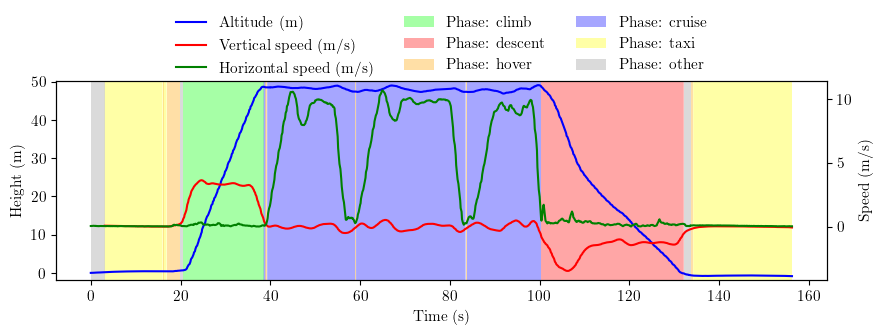

In [19]:
flight_id = 79

# ------------------ Define colors for phases ------------------
phase_colors = {
    "climb":   "rgba(0,255,0,0.35)",      # light green
    "descent": "rgba(255,0,0,0.35)",      # light red
    "hover":   "rgba(255,165,0,0.35)",    # light orange
    "cruise":  "rgba(0,0,255,0.35)",      # light blue
    "taxi":    "rgba(255,255,0,0.35)",    # light yellow
    "other":   "rgba(150,150,150,0.35)"   # light gray
}


# Create the matplotlib plot
fig = plot_flight_altitude_speed_matplotlib(
    df[df["flight"] == flight_id].copy(),
    phase_colors=phase_colors,
    show=False
)

plt.savefig('phases_plot.pdf', dpi=300, bbox_inches='tight')


In [16]:
def plot_flight_power_speed_matplotlib(
    d,
    phase_colors
):
    """
    Plot altitude, vertical speed, horizontal speed and phase bands using matplotlib.
    """
    # Prepare data
    y_min = d["power_w"].min() - 1
    y_max = d["power_w"].max() + 1

    # Create figure with twin axes
    fig, ax1 = plt.subplots(figsize=(text_width, text_width*0.48))
    ax2 = ax1.twinx()

    # ------------------ 1) Add Altitude (left axis) ------------------
    ax1.plot(d["time"], d["power_w"], color="C0", label="Power [W]")

    # ------------------ 2) Add Vertical Speed (right axis) ------------------
    ax2.plot(d["time"], d["wind_speed"], color="C1", label="Wind speed (m/s)")


    # ------------------ 3) Add Phase Bands as Filled Traces ------------------
    df = d.sort_values("time").reset_index(drop=True)

    # Prepare containers: one x/y list per phase
    bands = {
        phase: {"x": [], "y": []}
        for phase in phase_colors.keys()
    }

    # Iterate over each interval [time[i], time[i+1]]
    for i in range(len(df) - 1):
        phase = df.loc[i, "phase"]
        if phase not in phase_colors:
            continue  # skip phases you don't want to paint

        t0 = df.loc[i, "time"]
        t1 = df.loc[i + 1, "time"]

        # Build a small rectangle for this interval
        bands[phase]["x"] += [t0, t1, t1, t0, t0, None]
        bands[phase]["y"] += [y_min, y_min, y_max, y_max, y_min, None]

    legend_handles = []
    legend_labels = []

    # Now add one patch per phase
    for phase, color in phase_colors.items():
        x_band = bands[phase]["x"]
        y_band = bands[phase]["y"]
        if not x_band:
            continue

        # Convert RGBA string to matplotlib format
        # Parse rgba(0,255,0,0.35) to (0,1,0,0.35)
        if color.startswith('rgba'):
            # Extract values from rgba(0,255,0,0.35)
            rgba_vals = color[5:-1].split(',')
            r, g, b, a = [float(x.strip()) for x in rgba_vals]
            color_matplotlib = (r/255, g/255, b/255, a)
        else:
            color_matplotlib = color

        # Convert to polygon patches
        poly_collection = PolyCollection(
            [list(zip(x_band[:-1], y_band[:-1]))],
            facecolors=color_matplotlib,
            # alpha=1.0,  # Alpha is already handled by facecolor
            edgecolors='none'
        )
        ax1.add_collection(poly_collection)

        # # Create legend handle for this phase
        # legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_matplotlib))
        # legend_labels.append(f"Phase: {phase}")

    # ------------------ 4) Layout ------------------
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Power (W)")
    ax1.tick_params(axis='y')
    ax1.set_ylim(y_min, y_max)

    ax2.set_ylabel("Wind speed (m/s)")
    ax2.tick_params(axis='y')

    # Combine legends from both axes and phase bands
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    # Add phase legend handles
    all_lines = lines1 + lines2 + legend_handles
    all_labels = labels1 + labels2 + legend_labels

    ax1.legend(all_lines, all_labels, loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=3, frameon=False)

    plt.tight_layout()

    plt.subplots_adjust(top=0.60)
    return fig

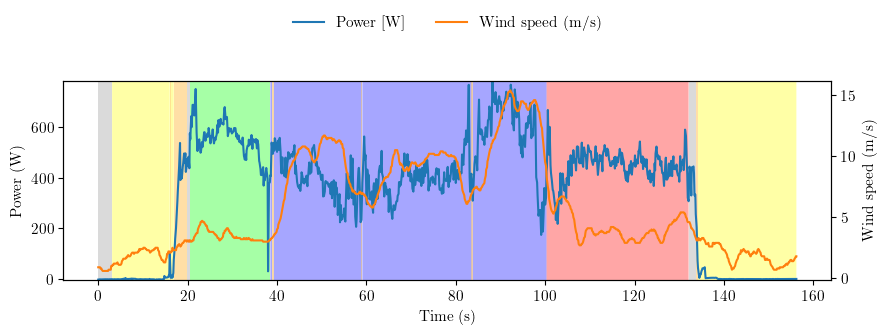

In [17]:
flight_id = 79

# ------------------ Define colors for phases ------------------
phase_colors = {
    "climb":   "rgba(0,255,0,0.35)",      # light green
    "descent": "rgba(255,0,0,0.35)",      # light red
    "hover":   "rgba(255,165,0,0.35)",    # light orange
    "cruise":  "rgba(0,0,255,0.35)",      # light blue
    "taxi":    "rgba(255,255,0,0.35)",    # light yellow
    "other":   "rgba(150,150,150,0.35)"   # light gray
}


# Create the matplotlib plot
fig = plot_flight_power_speed_matplotlib(
    df[df["flight"] == flight_id].copy(),
    phase_colors=phase_colors
)

plt.savefig('phases_power_plot.pdf', dpi=300, bbox_inches='tight')

### Task two

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [18]:
def compute_wind_vector(df):
    rad = np.deg2rad(df["wind_angle"])
    wind_x = -df["wind_speed"] * np.cos(rad)
    wind_y = -df["wind_speed"] * np.sin(rad)
    return wind_x, wind_y

def compute_rel_airspeed(df):
    wind_x, wind_y = compute_wind_vector(df)
    return np.sqrt(
        (df["velocity_x"] - wind_x)**2 +
        (df["velocity_y"] - wind_y)**2
    )

In [19]:
vz         = df["vz_from_alt"].values
segment    = df["phase"].values
df["payload_kg"] = df["payload"]/ 1000.0

# ------------------------------------------------------
# 2. Physical Parameters for DJI M100
# ------------------------------------------------------
g   = 9.81
rho = 1.225

m0   = 3.68                      # empty mass [kg]
mass = m0 + df["payload_kg"]           # total mass [kg]
w    = mass * g                  # weight [N]

# Rotor geometry (13-inch props)
radius = 0.165                   # rotor radius [m]
n_rotor = 4
area_rot  = np.pi * radius**2       # single rotor disk area [m^2]
disc_area  = n_rotor * area_rot               # total rotor disk area [m^2]

# Reference area & drag coefficient (from literature)
Cd    = 0.15                    # from external UAS paper
S_ref = 0.05           # S_ref = W*H*k = 0.65*0.22*0.35 width and height are from M100 mannual

# initiate a vector
P_mech_base = np.zeros_like(df["power_w"].values, dtype=float)


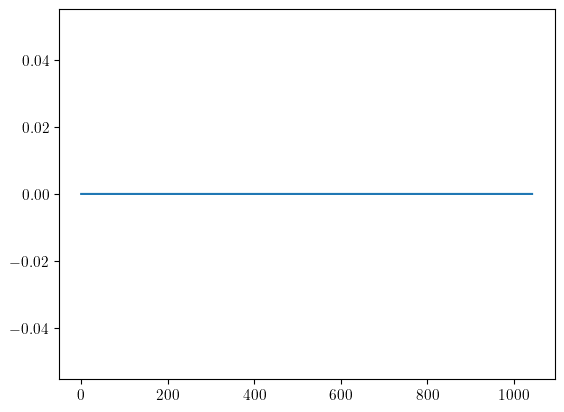

In [20]:
plt.plot(P_mech_base[df["flight"] == 79])

In [21]:
vh = np.sqrt(w / (2.0 * rho * disc_area))

P_hover = (w ** 1.5) / np.sqrt(2.0 * rho * disc_area)

P_mech_base[segment=="hover"] = P_hover[segment=="hover"]

In [22]:
px.line(P_mech_base[df["flight"] == 79])

In [23]:
# --- Climb ---
mask_climb = (segment == "climb")
if mask_climb.any():
    RoC   = df["vz_from_alt"][mask_climb]
    ratio = RoC / (2.0 * vh[mask_climb])
    P_mech_base[mask_climb] = P_hover[mask_climb] * (
        ratio + np.sqrt(ratio**2 + 1.0)
    )

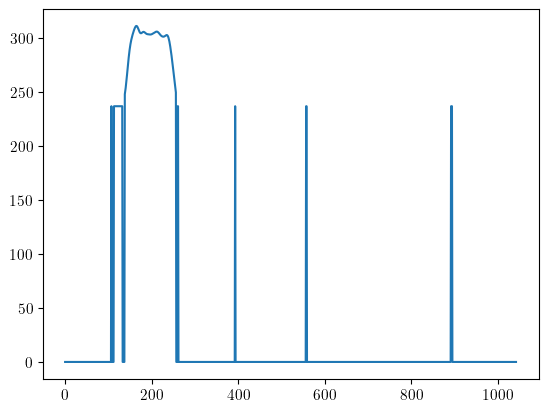

In [24]:
plt.plot(P_mech_base[df["flight"] == 79])

In [25]:
# --- Cruise ---
df["rel_airspeed"] = compute_rel_airspeed(df)
mask_cruise = (segment == "cruise")
if mask_cruise.any():
    Vc = df["rel_airspeed"][mask_cruise].values
    P_drag = 0.5 * rho * Cd * S_ref * (Vc**3)
    P_mech_base[mask_cruise] = P_hover[mask_cruise] + P_drag

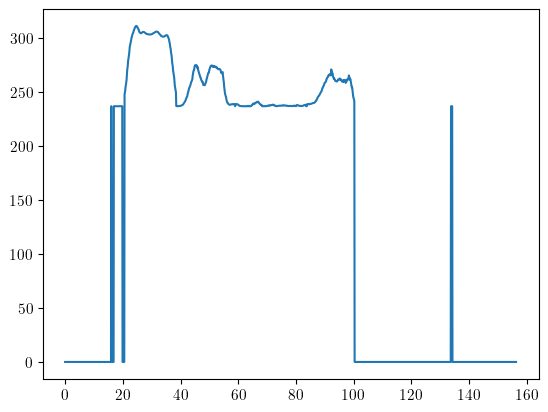

In [26]:
plt.plot(df[df["flight"] == 79]["time"], P_mech_base[df["flight"] == 79])

In [27]:
mask_descent = (segment == "descent")
if mask_descent.any():
    RoD   = vz[mask_descent]
    vh_d  = vh[mask_descent]
    ratio_d = RoD / (2.0 * vh_d)
    P_mech_base[mask_descent] = P_hover[mask_descent] * (
        ratio_d + np.sqrt(ratio_d**2 + 1.0)
    )

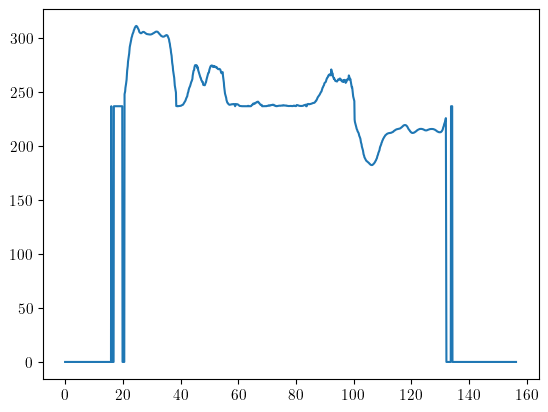

In [28]:
plt.plot(df[df["flight"] == 79]["time"], P_mech_base[df["flight"] == 79])

In [29]:
pd.Series(segment).unique()

array(['other', 'taxi', 'hover', 'climb', 'cruise', 'descent'],
      dtype=object)

In [30]:
# ------------------------------------------------------
# 5. Estimate Effective Efficiency η per Segment
# ------------------------------------------------------
eta_seg = { "hover": 0.829,
           "climb": 0.534,
           "descent": 0.462,
           "cruise": 0.525}

# ------------------------------------------------------
# 6. Build Final Battery Power Model
# ------------------------------------------------------
P_model_phys = np.full_like(P_mech_base, np.nan, dtype=float)

for s in ["hover", "climb", "descent", "cruise"]:
    mask_s = (segment == s)
    P_model_phys[mask_s] = P_mech_base[mask_s] / eta_seg[s]

df["P_model_phys"] = P_model_phys

P_real = df["power_w"].values
# ------------------------------------------------------
# 7. Evaluate Power Model Accuracy
# ------------------------------------------------------
valid_eval = (P_real > 30) & (segment != "other") & ~np.isnan(P_model_phys)

MAE  = mean_absolute_error(P_real[valid_eval], P_model_phys[valid_eval])
RMSE = np.sqrt(mean_squared_error(P_real[valid_eval], P_model_phys[valid_eval]))
MAPE = (np.abs(P_model_phys[valid_eval] - P_real[valid_eval]) /
        P_real[valid_eval]).mean() * 100.0

print("\n===== FINAL PHYSICS MODEL RESULTS =====")
print(f"MAE  = {MAE:.2f} W")
print(f"RMSE = {RMSE:.2f} W")
print(f"MAPE = {MAPE:.2f} %")


print("\n===== ERROR BY SEGMENT (NO TRANSITION) =====")
for s in ["hover", "climb", "descent", "cruise"]:
    mask_s = (segment == s) & (P_real > 30) & ~np.isnan(P_model_phys)
    if mask_s.sum() < 50:
        continue
    mae_s  = mean_absolute_error(P_real[mask_s], P_model_phys[mask_s])
    rmse_s = np.sqrt(mean_squared_error(P_real[mask_s], P_model_phys[mask_s]))
    mape_s = np.mean(np.abs(P_model_phys[mask_s] - P_real[mask_s]) / P_real[mask_s]) * 100
    print(f"{s:10s} | N={mask_s.sum():6d} | MAE={mae_s:8.2f} | RMSE={rmse_s:8.2f} | MAPE={mape_s:8.2f}%")
    #print(f"{s:10s} | N={mask_s.sum():6d} | MAE={mae_s:8.2f} | RMSE={rmse_s:8.2f} | MAPE={mape_s:6.2f}%")


===== FINAL PHYSICS MODEL RESULTS =====
MAE  = 59.33 W
RMSE = 83.53 W
MAPE = 14.24 %

===== ERROR BY SEGMENT (NO TRANSITION) =====
hover      | N=  9489 | MAE=  185.36 | RMSE=  196.14 | MAPE=   84.86%
climb      | N= 29949 | MAE=   56.99 | RMSE=   82.64 | MAPE=   10.48%
descent    | N= 48264 | MAE=   45.71 | RMSE=   64.36 | MAPE=    9.58%
cruise     | N=103112 | MAE=   54.79 | RMSE=   73.81 | MAPE=   11.01%


### Task 3

In [31]:
allowed_phases = ["cruise", "descent", "climb", "hover"]

df["phase"] = df["phase"].str.lower().str.strip()   # normalize

df_filtered = df[df["phase"].isin(allowed_phases)]

In [32]:
import math
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# ========= 1. Quaternion → roll, pitch, yaw =========
# Quaternion assumed in (x, y, z, w) convention

def quat_to_euler(x, y, z, w):
    # Normalize to avoid numerical issues
    norm = math.sqrt(x*x + y*y + z*z + w*w)
    if norm == 0:
        return 0.0, 0.0, 0.0
    x /= norm
    y /= norm
    z /= norm
    w /= norm

    # roll (x-axis rotation)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(sinr_cosp, cosr_cosp)

    # pitch (y-axis rotation)
    sinp = 2.0 * (w * y - z * x)
    if abs(sinp) >= 1:
        # use 90 degrees if out of range
        pitch = math.copysign(math.pi / 2.0, sinp)
    else:
        pitch = math.asin(sinp)

    # yaw (z-axis rotation)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(siny_cosp, cosy_cosp)

    return roll, pitch, yaw

# Apply to the whole dataframe
rpy = df_filtered.apply(
    lambda row: pd.Series(
        quat_to_euler(
            row["orientation_x"],
            row["orientation_y"],
            row["orientation_z"],
            row["orientation_w"],
        ),
        index=["roll", "pitch", "yaw"],
    ),
    axis=1,
)

df_filtered = pd.concat([df_filtered, rpy], axis=1)

In [33]:
df_filtered["phase"] = df_filtered["phase"].str.lower().str.strip()

df_filtered["is_cruise"]  = df_filtered["phase"] == "cruise"
df_filtered["is_climb"]   = df_filtered["phase"] == "climb"
df_filtered["is_descent"] = df_filtered["phase"] == "descent"
df_filtered["is_hover"]   = df_filtered["phase"] == "hover"

In [34]:
df_79 = df_filtered[df_filtered["flight"] == 79]
df_filtered = df_filtered[df_filtered["flight"] != 79]

In [35]:
# ========= 2. Define features & target =========
target_col = "power_w"

feature_cols = ['wind_speed',
                'wind_angle',
                'roll',
                'pitch',
                'yaw',
                'velocity_x',
                'velocity_y',
                'velocity_z',
                'vz_from_alt',
                'angular_x',
                'angular_y',
                'angular_z',
                'linear_acceleration_x',
                'linear_acceleration_y',
                'linear_acceleration_z',
                'is_cruise',
                'is_climb',
                'is_descent',
                'is_hover']

X = df_filtered[feature_cols]
y = df_filtered[target_col]


# ========= 3. Train / test split =========
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
# ========= 4. Train Random Forest model =========
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
# ========= 6. Evaluate =========
y_pred = rf.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", rmse)

# Optional: see feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False))


Test RMSE: 49.84243770978401
velocity_z               0.247326
linear_acceleration_z    0.147634
yaw                      0.085795
is_hover                 0.071556
roll                     0.065018
wind_speed               0.061355
vz_from_alt              0.052841
velocity_y               0.041760
wind_angle               0.035117
velocity_x               0.034551
pitch                    0.031558
angular_z                0.027229
linear_acceleration_y    0.026739
linear_acceleration_x    0.025056
angular_x                0.022727
angular_y                0.022679
is_cruise                0.000405
is_climb                 0.000333
is_descent               0.000321
dtype: float64


In [38]:
MAE  = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
MAPE = (np.abs(y_pred - y_test) /
        y_test).mean() * 100.0

print("\n===== FINAL RANDOM FOREST MODEL RESULTS =====")
print(f"MAE  = {MAE:.2f} W")
print(f"RMSE = {RMSE:.2f} W")
print(f"MAPE = {MAPE:.2f} %")

print("\n===== ERROR BY SEGMENT (NO TRANSITION) =====")
for s in ["hover", "climb", "descent", "cruise"]:
    mask_s = X_test["is_" + s]
    mae_s  = mean_absolute_error(y_test[mask_s], y_pred[mask_s])
    rmse_s = np.sqrt(mean_squared_error(y_test[mask_s], y_pred[mask_s]))
    mape_s = np.mean(np.abs(y_pred[mask_s] - y_test[mask_s]) / y_test[mask_s]) * 100
    print(f"{s:10s} | MAE={mae_s:8.2f} | RMSE={rmse_s:8.2f} | MAPE={mape_s:8.2f}%")
#     print(f"{s:10s} | N={mask_s.sum():6d} | MAE={mae_s:8.2f} | RMSE={rmse_s:8.2f}")



===== FINAL RANDOM FOREST MODEL RESULTS =====
MAE  = 36.08 W
RMSE = 49.84 W
MAPE = 7.85 %

===== ERROR BY SEGMENT (NO TRANSITION) =====
hover      | MAE=   46.69 | RMSE=   74.98 | MAPE=   20.60%
climb      | MAE=   33.39 | RMSE=   46.40 | MAPE=    6.17%
descent    | MAE=   33.37 | RMSE=   46.92 | MAPE=    7.21%
cruise     | MAE=   37.14 | RMSE=   49.21 | MAPE=    7.46%


In [39]:
def plot_flight_power_compare(
    d,
    phase_colors
):
    """
    Plot altitude, vertical speed, horizontal speed and phase bands using matplotlib.
    """
    # Prepare data
    y_min = d["power_w"].min() - 1
    y_max = d["power_w"].max() + 1

    # Create figure with twin axes
    fig, ax1 = plt.subplots(figsize=(text_width, text_width*0.48))

    # ------------------ 1) Add Altitude (left axis) ------------------
    ax1.plot(d["time"], d["power_w"], color="C0", label="Battery power [W]")

    # ------------------ 2) Add Vertical Speed (right axis) ------------------
    ax1.plot(d["time"], d["P_model_phys"], color="C1", label="Physical model [W]")
    pred_power = rf.predict(df_79[feature_cols])
    ax1.plot(df_79["time"], pred_power, color="C2", label="Random forest [W]")

    # ------------------ 3) Add Phase Bands as Filled Traces ------------------
    df = d.sort_values("time").reset_index(drop=True)

    # Prepare containers: one x/y list per phase
    bands = {
        phase: {"x": [], "y": []}
        for phase in phase_colors.keys()
    }

    # Iterate over each interval [time[i], time[i+1]]
    for i in range(len(df) - 1):
        phase = df.loc[i, "phase"]
        if phase not in phase_colors:
            continue  # skip phases you don't want to paint

        t0 = df.loc[i, "time"]
        t1 = df.loc[i + 1, "time"]

        # Build a small rectangle for this interval
        bands[phase]["x"] += [t0, t1, t1, t0, t0, None]
        bands[phase]["y"] += [y_min, y_min, y_max, y_max, y_min, None]

    legend_handles = []
    legend_labels = []

    # Now add one patch per phase
    for phase, color in phase_colors.items():
        x_band = bands[phase]["x"]
        y_band = bands[phase]["y"]
        if not x_band:
            continue

        # Convert RGBA string to matplotlib format
        # Parse rgba(0,255,0,0.35) to (0,1,0,0.35)
        if color.startswith('rgba'):
            # Extract values from rgba(0,255,0,0.35)
            rgba_vals = color[5:-1].split(',')
            r, g, b, a = [float(x.strip()) for x in rgba_vals]
            color_matplotlib = (r/255, g/255, b/255, a)
        else:
            color_matplotlib = color

        # Convert to polygon patches
        poly_collection = PolyCollection(
            [list(zip(x_band[:-1], y_band[:-1]))],
            facecolors=color_matplotlib,
            # alpha=1.0,  # Alpha is already handled by facecolor
            edgecolors='none'
        )
        ax1.add_collection(poly_collection)

        # # Create legend handle for this phase
        # legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_matplotlib))
        # legend_labels.append(f"Phase: {phase}")

    # ------------------ 4) Layout ------------------
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Power (W)")
    ax1.tick_params(axis='y')
    ax1.set_ylim(y_min, y_max)

    # Combine legends from both axes and phase bands
    lines1, labels1 = ax1.get_legend_handles_labels()

    # Add phase legend handles
    all_lines = lines1  + legend_handles
    all_labels = labels1  + legend_labels

    ax1.legend(all_lines, all_labels, loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=3, frameon=False)

    plt.tight_layout()

    plt.subplots_adjust(top=0.60)
    return fig

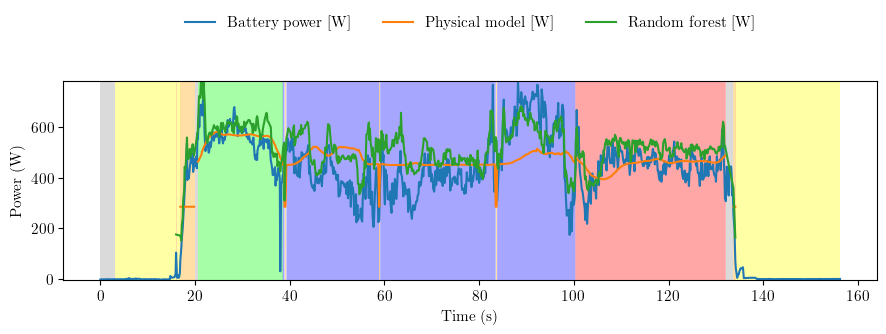

In [40]:
# Create the matplotlib plot
fig = plot_flight_power_compare(
    df[df["flight"] == flight_id].copy(),
    phase_colors=phase_colors
)

plt.savefig('phases_power_compare.pdf', dpi=300, bbox_inches='tight')

## Energy consumption

In [ ]:
# Ensure time is numeric and sorted within each flight and phase
df = df.sort_values(['flight', 'phase', 'time'])

# Initialize a list to store results
energy_results = []

# Iterate over each flight_id and phase combination
for (flight_id, phase), group in df.groupby(['flight', 'phase']):
    # Ensure time is sorted within the group
    group = group.sort_values('time')

    # Extract time and power
    t = group['time'].values
    p = group['power_w'].values

    # Compute energy using trapezoidal rule (in joules)
    energy_joules = np.trapezoid(p, x=t)

    # Append result
    energy_results.append({
        'flight_id': flight_id,
        'phase': phase,
        'energy_joules': energy_joules
    })

# Convert to DataFrame
energy_df = pd.DataFrame(energy_results)

# Optional: Convert to kWh for better interpretability
energy_df['energy_kwh'] = energy_df['energy_joules'] / 3.6e6

# Display results
print(energy_df)

      flight_id    phase  energy_joules  energy_kwh
0             1    climb   12730.012615    0.003536
1             1   cruise   43785.928899    0.012163
2             1  descent   61083.892707    0.016968
3             1    hover   51214.502549    0.014226
4             1    other   60341.829248    0.016762
...         ...      ...            ...         ...
1208        279   cruise    1386.469113    0.000385
1209        279  descent   22366.948051    0.006213
1210        279    hover   35955.616872    0.009988
1211        279    other   58754.986829    0.016321
1212        279     taxi    3010.068890    0.000836

[1213 rows x 4 columns]
